In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [16]:
df = pd.read_csv('/content/calories.csv')
df2 = pd.read_csv('/content/exercise.csv')
df = pd.concat([df,df2], axis=1)

df = df.loc[:,~df.columns.duplicated()].copy()

df.head()


,User_ID,Calories,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,231.0,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,66.0,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,26.0,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,71.0,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,35.0,female,27,154.0,58.0,10.0,81.0,39.8


In [17]:
df.describe()

,User_ID,Calories,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,89.539533,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453
std,2.872851e+06,62.456978,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230
min,1.000116e+07,1.000000,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000
25%,1.247419e+07,35.000000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000
50%,1.499728e+07,79.000000,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000
75%,1.744928e+07,138.000000,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000
max,1.999965e+07,314.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000


<Axes: xlabel='Height', ylabel='Weight'>

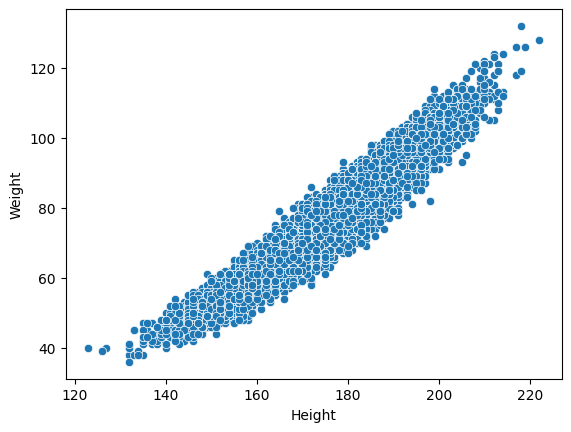

In [18]:
sb.scatterplot(x="Height",y="Weight",data=df2)

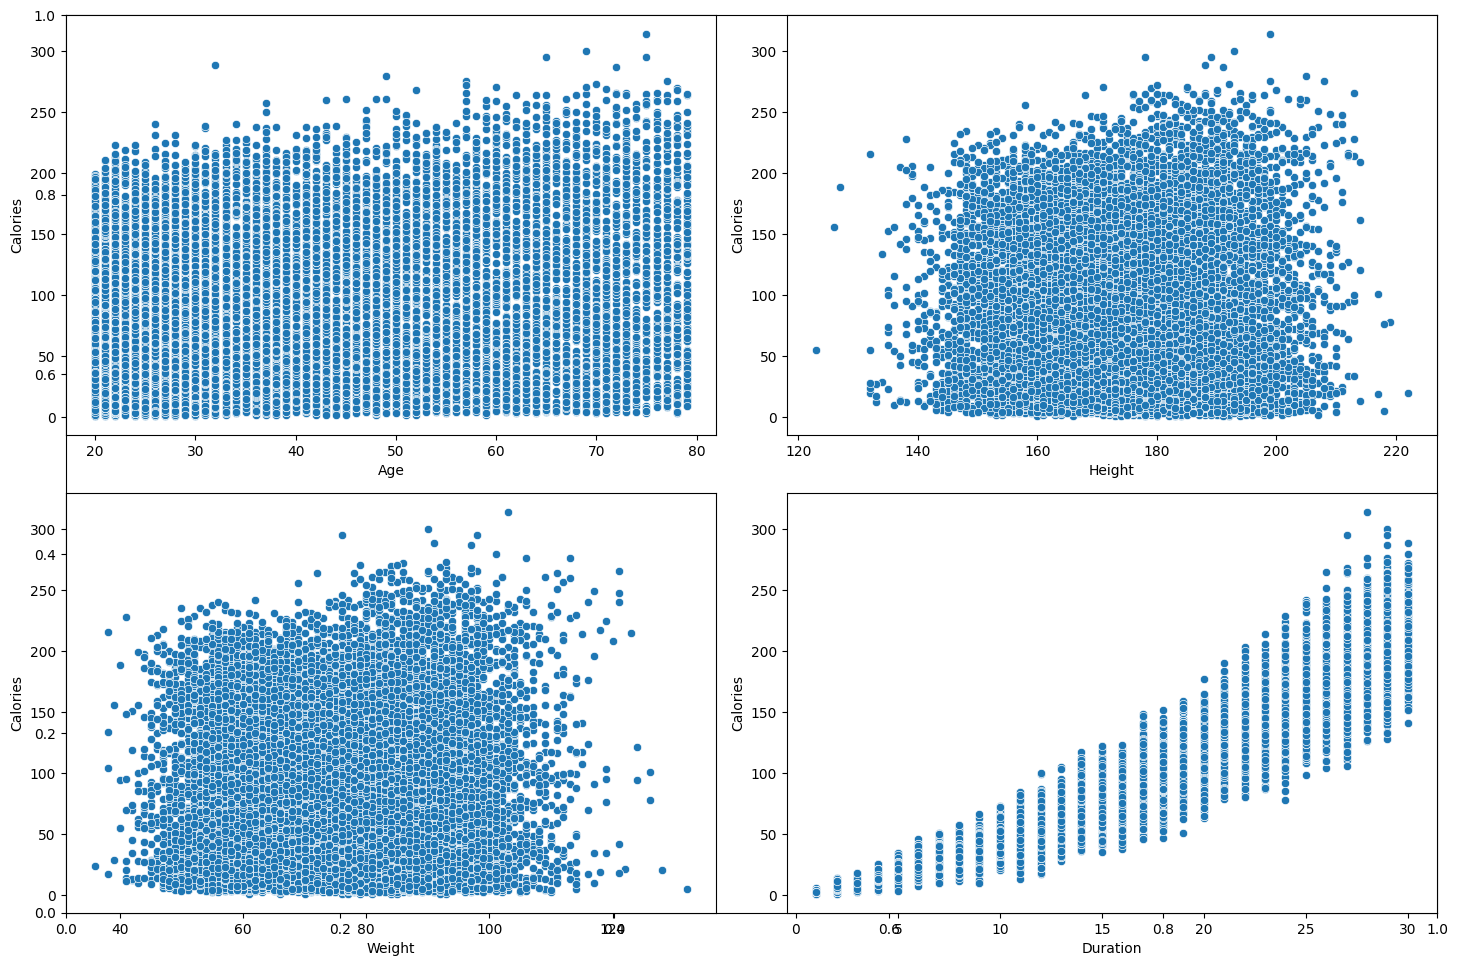

In [19]:
features = ['Age', 'Height', 'Weight', 'Duration']

plt.subplots(figsize=(15,10))
for i, col in enumerate(features):
    plt.subplot(2,2,i+1)
    x=df.sample(1000)
    sb.scatterplot(x=col,y='Calories',data=df)
plt.tight_layout()
plt.show()




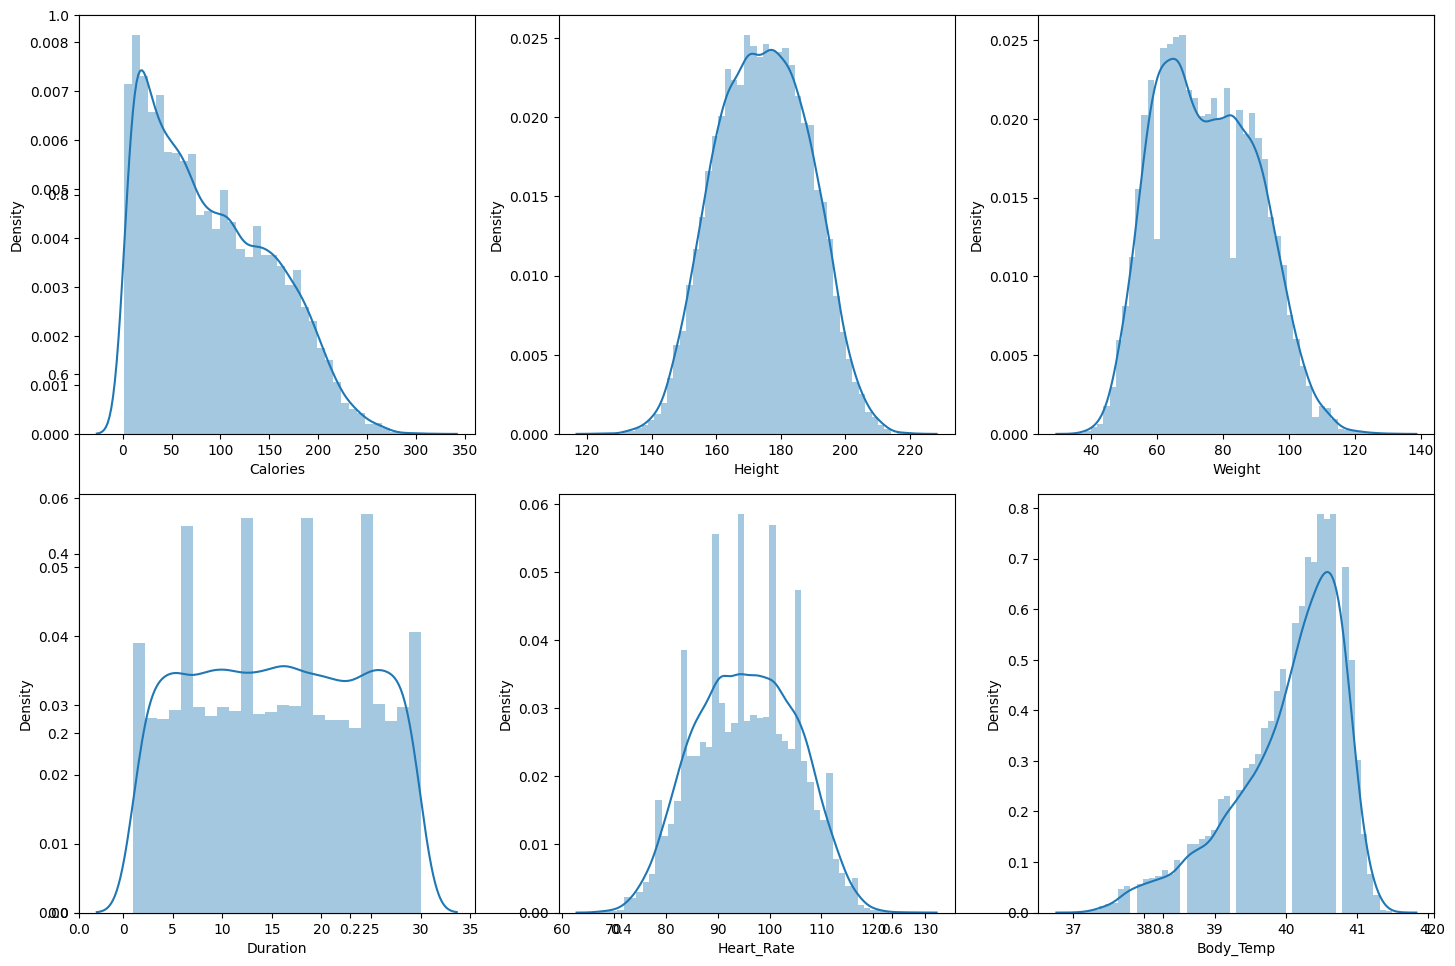

In [20]:
features = df.select_dtypes(include='float').columns

plt.subplots(figsize=(15,10))
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.distplot(df[col])
plt.tight_layout()
plt.show()

In [21]:
df.replace({'male' :0, 'female' : 1}, inplace=True)
df.head()

,User_ID,Calories,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,231.0,0,68,190.0,94.0,29.0,105.0,40.8
1,14861698,66.0,1,20,166.0,60.0,14.0,94.0,40.3
2,11179863,26.0,0,69,179.0,79.0,5.0,88.0,38.7
3,16180408,71.0,1,34,179.0,71.0,13.0,100.0,40.5
4,17771927,35.0,1,27,154.0,58.0,10.0,81.0,39.8


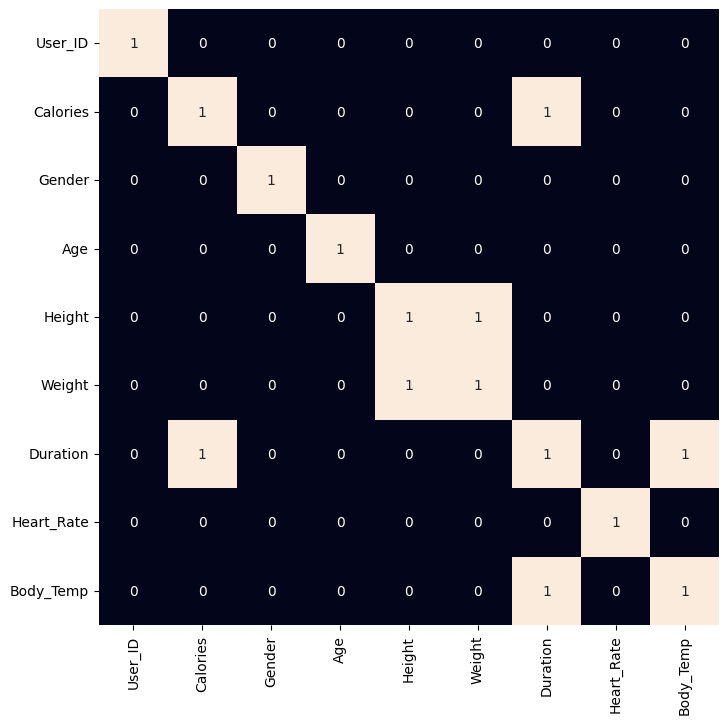

In [22]:
plt.figure(figsize=(8,8))
sb.heatmap(df.corr() > 0.9, annot = True, cbar=False)
plt.show()

In [24]:
to_remove = ['Weight', 'Duration']
df.drop(to_remove, axis=1, inplace=True)

In [26]:
features = df.drop(['User_ID', 'Calories'], axis=1)
target = df['Calories'].values

X_train, X_val, y_train, y_val = train_test_split(features, target, test_size=0.1, random_state=22)

X_train.shape, X_val.shape

((13500, 5), (1500, 5))

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [30]:
from sklearn.metrics import mean_absolute_error as mae

models = [LinearRegression(), Lasso(), Ridge(), RandomForestRegressor(), XGBRegressor()]

for model in models:
  model.fit(X_train, y_train)
  print(f'{model} : ')

  train_preds = model.predict(X_train)
  print('Training Error : ', mae(y_train, train_preds))

  val_preds = model.predict(X_val)
  print('Validation Error : ', mae(y_val, val_preds))
  print()

LinearRegression() : 
Training Error :  17.893463692619434
Validation Error :  18.007896272831253

Lasso() : 
Training Error :  17.915089584958036
Validation Error :  17.995033362288662

Ridge() : 
Training Error :  17.893530494767777
Validation Error :  18.00781790803129

RandomForestRegressor() : 
Training Error :  3.967064615520282
Validation Error :  10.520478476190476

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
        